In [1]:
import matplotlib.pyplot as plt
import numpy as np
from nilearn import datasets, plotting
from nilearn.surface import load_surf_mesh

from src import surface

fsaverage = datasets.fetch_surf_fsaverage(mesh="fsaverage4")
surface_mesh = load_surf_mesh(fsaverage.pial_left)
print(
    f"'pial_mesh.coordinates' shape: {surface_mesh.coordinates.shape}",
    f"'pial_mesh.faces' shape: {surface_mesh.faces.shape}",
    sep="\n",
)

'pial_mesh.coordinates' shape: (2562, 3)
'pial_mesh.faces' shape: (5120, 3)


In [2]:
# !!! 30sec runtime !!!
def estimate_rho_hat(x1, x2):
    """Estimate the sample correlation (`rho hat`) between two vectors."""
    return x1.dot(x2) / x1.shape[0]


# initialize parameters
rng = np.random.default_rng(seed=0)
n_vertices = surface_mesh.coordinates.shape[0]
n_simulations = 1000
rhos = [0.0, 0.3, 0.6, 0.9]

# initialize simulation results
simulations = {
    f"{rho}-{suffix}": np.zeros(n_simulations)
    for rho in rhos
    for suffix in ["mvnormal", "smoothed"]
}

for rho in rhos:
    for i in range(n_simulations):
        # generate Xs
        X = rng.multivariate_normal([0, 0], [[1, rho], [rho, 1]], size=n_vertices)
        X = X - X.mean(axis=0)  # mean center
        X_smoothed = surface.smooth_surface_data(surface_mesh, X, iterations=10, match="dist")

        # estimate rho hats
        X_rho_hat = estimate_rho_hat(X[:, 0], X[:, 1])
        X_smoothed_rho_hat = estimate_rho_hat(X_smoothed[:, 0], X_smoothed[:, 1])

        # save estimates for plotting
        simulations[f"{rho}-mvnormal"][i] = X_rho_hat
        simulations[f"{rho}-smoothed"][i] = X_smoothed_rho_hat

Text(0.5, 1.0, '$\\hat{\\rho}_\\text{smoothed}$')

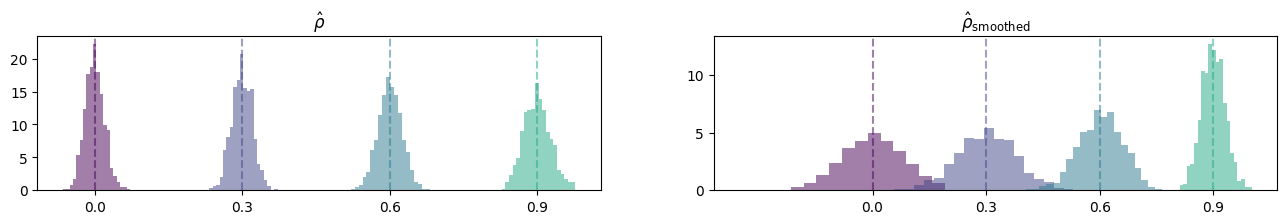

In [3]:
# plot simulations
colors = plt.cm.viridis(np.linspace(0, 1, len(rhos) + 2))
hist_kwargs = dict(bins=20, alpha=0.5, density=True)
vline_kwargs = dict(ls="--", alpha=0.5)

fig, axs = plt.subplots(1, 2, figsize=(16, 2))
for rho, color in zip(rhos, colors):
    axs[0].hist(simulations[f"{rho}-mvnormal"], color=color, **hist_kwargs)
    axs[0].axvline(rho, color=color, **vline_kwargs)
    axs[1].hist(simulations[f"{rho}-smoothed"], color=color, **hist_kwargs)
    axs[1].axvline(rho, color=color, **vline_kwargs)

axs[0].set_xticks(rhos)
axs[1].set_xticks(rhos)
axs[0].set_title(r"$\hat{\rho}$")
axs[1].set_title(r"$\hat{\rho}_\text{smoothed}$")

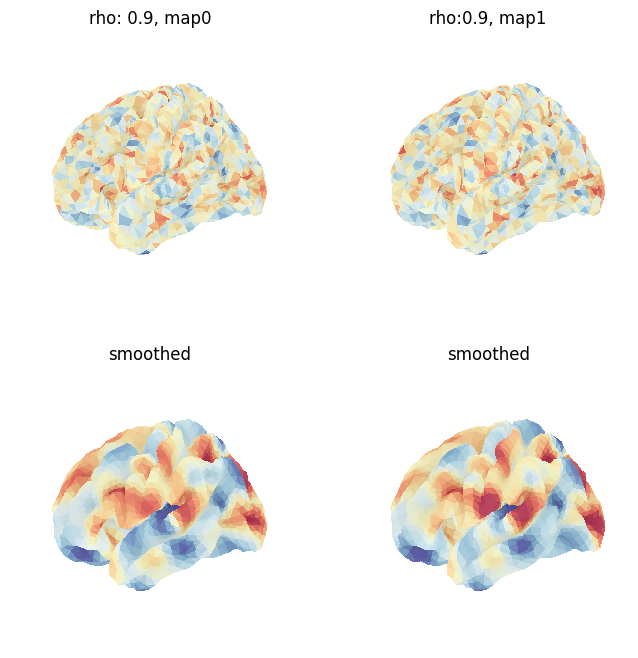

In [4]:
# plot example surface maps
plot_surf_kwargs = dict(bg_map=fsaverage.sulc_left, bg_on_data=True, cmap="RdYlBu", vmin=-2, vmax=2)

fig, axs = plt.subplots(2, 2, figsize=(8, 8), subplot_kw={"projection": "3d"})
plotting.plot_surf(
    surface_mesh, X[:, 0], axes=axs[0, 0], title=f"rho: {rho}, map0", **plot_surf_kwargs
)
plotting.plot_surf(
    surface_mesh, X[:, 1], axes=axs[0, 1], title=f"rho:{rho}, map1", **plot_surf_kwargs
)
plotting.plot_surf(
    surface_mesh, X_smoothed[:, 0], title="smoothed", axes=axs[1, 0], **plot_surf_kwargs
)
plotting.plot_surf(
    surface_mesh, X_smoothed[:, 1], title="smoothed", axes=axs[1, 1], **plot_surf_kwargs
)
pass